# Neurotransmitter Probability Variance across Drosophila Neuropils

This projects aims to answer - how do neurotransmitter probability distributions vary across neuropils in Drosophila?
The datasets should be downloaded into the data directory following the instructions on GitHub. 

## Stage 0: Set up environment

In [1]:
%load_ext autoreload 
%autoreload 2

# Import external libraries
import dask
from IPython.core.display import HTML, Image
from IPython.display import IFrame
import pyvista as pv
from dask.distributed import Client

# Import core python libraries
import os

# Import local scripts (brainz.py, pipeline.py, plotting.py, 
# preprocess.py)
from scripts import *

In [2]:
# Set up in-line 3D plot rendering
pv.set_jupyter_backend("client")

In [3]:
# Set globals
OUTDIR = os.path.join(os.path.dirname(__name__), "results", "notebook")
if not os.path.exists(OUTDIR): os.mkdir(OUTDIR)
MINSIZE = 30 # Minimum number of nodes in a cluster/community

In [4]:
allow_bytes = pipeline.get_ram_allowance() # Allow Dask to use just over 60% of system RAM
PARTITION_SIZE = pipeline.get_partition_size(num_threads = 4, allow_bytes = allow_bytes)
client = pipeline.start_dask(num_threads = 4, allow_bytes = allow_bytes)
dask.config.set({"dataframe.shuffle.method": "tasks"})
preprocess.run() # ~10 mins first run

15.8 GiB available on machine; allowing 9.5 GiB

Dask Dashboard at http://192.168.0.134:8787/status

Notice: this may take some time if this is the first time running preprocess.py.


16:20:39 Preprocessing complete!


## Stage 1: Load Data

This stage of the pipeline loads and merges data from file, creating a single cohesive dataframe containing metadata for every synapse belonging to a neuron-neuron connection in proofread_connections_783.parquet. 

Neurotransmitter probability normalisation is required because the probabilities of some points do not sum to exactly 1 across all 6 neurotransmitters, but Dirichlet regression and composition analysis requires these probabilities to sum to exactly 1. Additionally, neurotransmitter normalisation reduces the data from 6 compositional variables to 3 compositional variables: GABA, an inhibitory neurotransmitter; Acetylcholine ('ach'), an excitatory neurotransmitter, and 'other', which encompasses the remaining neurotransmitters which cannot be reliably classified as solely inhibitory or excitatory (rather, they are usually neuromodulators).

Although the proofread connections file contains a compact representation of synapse data already (synapse count, and the same neurotransmitter probabilities allocated to each synapse), this stage of the pipeline expands the compact representation back to representing one synapse per row. This is because compositional analysis of neurotransmitter probabilities across synapses (e.g., in Dirichlet regression and in plotting ternary plots) requires this expanded format. 

In [5]:
# Choose dataset to use. Note the decisions made in this notebook are based
# on the full connectome dataset (proofread_connections_783.parquet). The
# other datasets are selections of different neuropils, and are provided for
# debugging/testing purposes.

#DATASET = "data/proofread_connections_783.parquet" # ~ 1.05 GB

#DATASET = "data/large.parquet" # ~ 583 MB
#DATASET = "data/medium.parquet" # ~ 272 MB
#DATASET = "data/small.parquet" # ~ 56 MB
DATASET = "data/tiny.parquet" # ~ 215 KB

In [6]:
pipeline.relax_memory_limits() # Let Dask use a higher percentage of allocated RAM

In [7]:
connectome = pipeline.load_connectome(DATASET, PARTITION_SIZE)
connectome.head(3, npartitions=1).style.hide(axis="index")

16:20:39 Loading connectome ...
16:20:40 Connectome loaded


pre,post,neuropil,gaba,ach,glut,oct,ser,da
720575940632372141,720575940630202267,BU_R,0.017462,0.945352,0.003710,0.000351,0.005212,0.027913
720575940628837650,720575940624992007,BU_R,0.001160,0.993029,0.000243,0.000404,0.000005,0.005160
720575940640173646,720575940639278399,BU_R,0.015524,0.767869,0.027776,0.016885,0.032855,0.139091


In [8]:
connectome = pipeline.normalise_nt_probs(connectome)
connectome.head(3, npartitions=1).style.hide(axis="index")

16:20:40 Normalising neurotransmitter probabilities ...
16:20:42 Neurotransmitter probabilities normalised


pre,post,neuropil,gaba,ach,other
720575940632372141,720575940630202267,BU_R,0.017462,0.945352,0.037187
720575940628837650,720575940624992007,BU_R,0.001160,0.993029,0.005812
720575940640173646,720575940639278399,BU_R,0.015524,0.767869,0.216607


In [9]:
# This step takes a little longer because it merges the 1 GB 
# proofread_synapses_783.parquet file with the ~13 GB 
# flywire_synapses_783.parquet file. 
# Took ~2 min with ~8 GB RAM allowance and 4 threads.
connectome = pipeline.attach_synapse_coords(connectome, PARTITION_SIZE)
connectome.head(3, npartitions=1).style.hide(axis="index")

16:20:42 Attaching coordinates ...


C:\Users\cielb\anaconda3\envs\nta2\Lib\site-packages\dask\dataframe\dask_expr\_collection.py:318: UserWarning: Dask annotations {'resources': {'shuffle': 1}} detected. Annotations will be ignored when using query-planning.
  warnings.warn(


16:21:58 Coordinates attached


index,pre,post,neuropil,gaba,ach,other,x,y,z
0,720575940626925843,720575940622991252,BU_R,0.025022,0.922210,0.052767,877122,280944,135560
1,720575940626925843,720575940622991252,BU_R,0.025022,0.922210,0.052767,882240,278270,129380
2,720575940619845547,720575940627890072,BU_R,0.000164,0.000016,0.999821,787784,242696,163340


In [10]:
connectome = pipeline.attach_neuropil_metadata(connectome)
connectome.head(3, npartitions=1).style.hide(axis="index")

16:23:08 Attaching neuropil metadata ...
16:23:09 Neuropil metadata attached


index,pre,post,neuropil,gaba,ach,other,x,y,z,region,neuropil_desc
0,720575940626925843,720575940622991252,BU_R,0.025022,0.922210,0.052767,877122,280944,135560,Lateral Complex,bulb (in lateral complex)
1,720575940626925843,720575940622991252,BU_R,0.025022,0.922210,0.052767,882240,278270,129380,Lateral Complex,bulb (in lateral complex)
2,720575940619845547,720575940627890072,BU_R,0.000164,0.000016,0.999821,787784,242696,163340,Lateral Complex,bulb (in lateral complex)


In [11]:
pipeline.restore_memory_limits() # Next stages are heavy on unmanaged memory

## Stage 2: Identify & Visualise Neurotransmitter Clusters

This step identifies frequent cluster compositions and allocates each point to either a frequent cluster or labels it as 'noise'. A brain map is then plotted, with each point's colour corresponding to its allocated neurotransmitter cluster. Although this approach requires extra effort and will be harder to automate in the future, it is superior to the naive approach of labelling each point on a brain map by the neurotransmitter with the highest probability for that edge. This is because the latter approach ignores important compositional information and can lump two very different neurotransmitter ratios into the same group (e.g., a point with 100% acetylcholine probability would be labelled in the same manner as a point with 34% acetylcholine, 33% gaba, and 33% other probabilities).

### Visualise Initial Neurotransmitter Probability Distribution

In [12]:
connectome_nts = connectome[["gaba", "ach", "other"]]

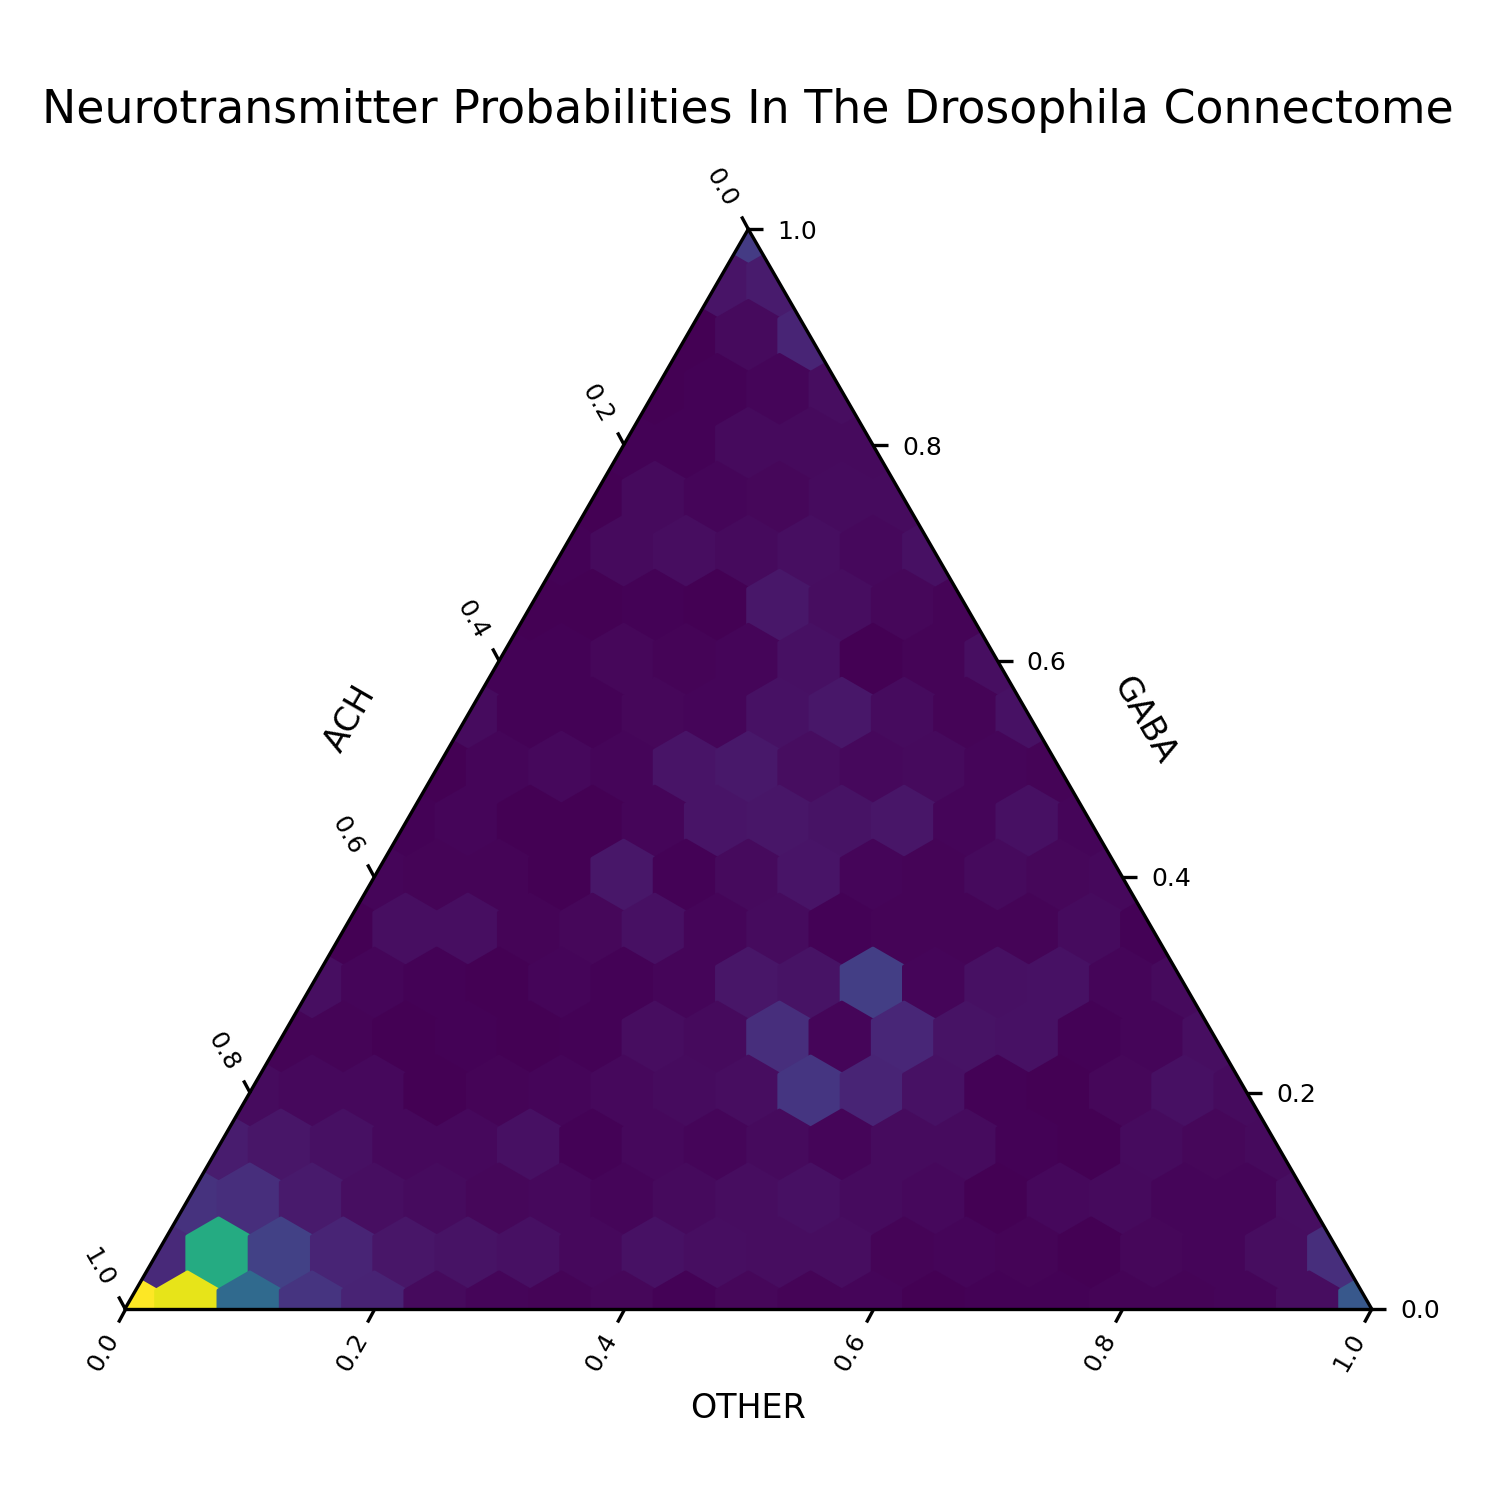

In [13]:
# Sample connectome - hexbin plotting is memory-intensive and don't need every data point to get idea of distribution
sample = pipeline.downsample(connectome_nts, 50_000, allow_bytes)
filename = os.path.join(OUTDIR, "init_overall_distribution.png")
pipeline.make_plot("plot_n_ternary", filename, samples = [sample], labels = ["Neurotransmitter_Probabilities_In_The_Drosophila_Connectome"])
Image(filename, width = 600)

### Divide synapses into 4 initial categories

The above ternary plot shows that the majority of synapses can be categorised as high ACH. Additionally, some can be categorised as high GABA and some as high OTHER. It does appear there may be some synapses that cannot be easily classified into any of these three corner categories. I will classify these as 'unclassified' for now. See the tag_clusters() function in the pipeline script for my choice of cluster boundaries. Note the results may vary slightly with slightly different boundaries.

In [14]:
# Extract and visualise the four initial clusters
connectome = pipeline.tag_clusters(connectome)
sample = pipeline.downsample(connectome, 50_000, allow_bytes)

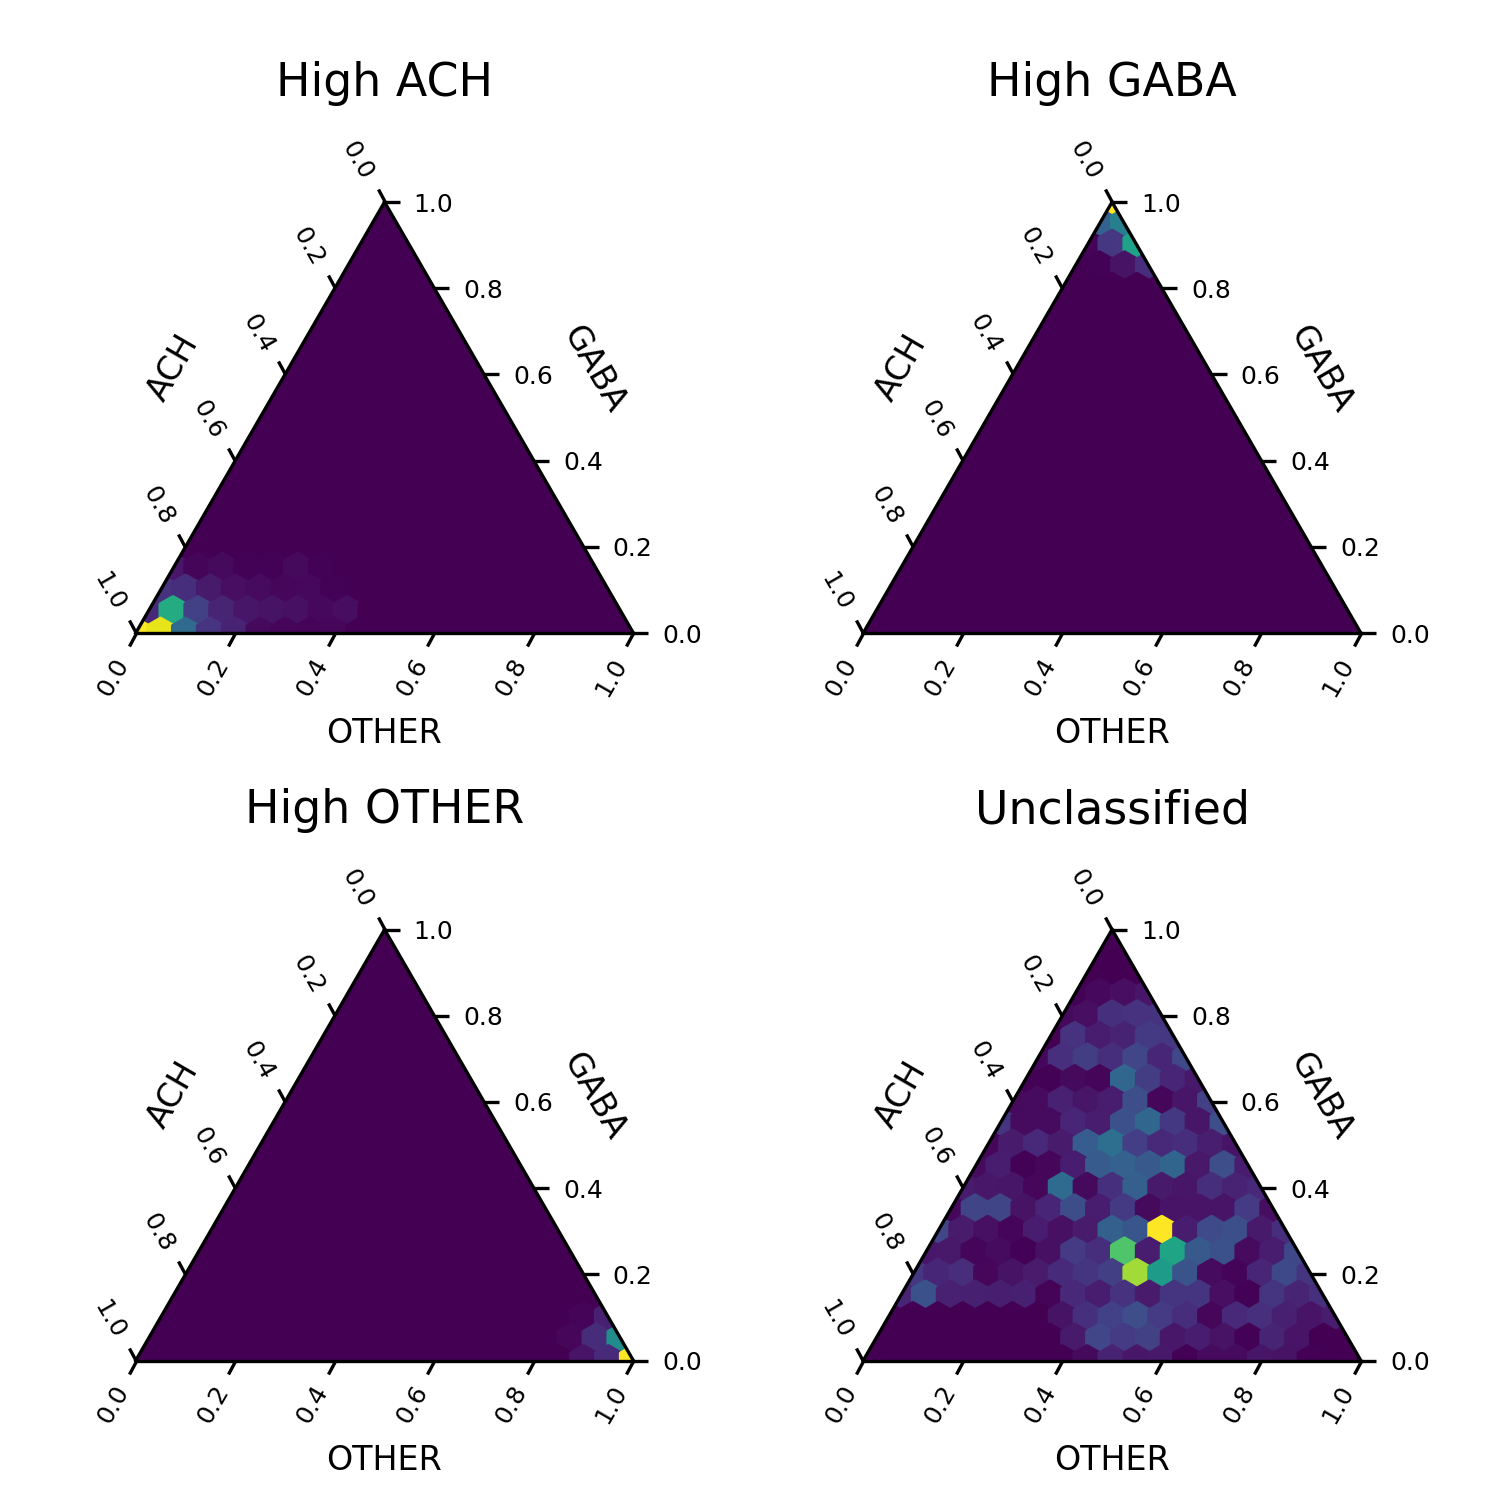

In [15]:
# Plot hex plots of new cluster classifications
grouped = sample.groupby("cluster")
high_gaba_sample = grouped.get_group("gaba")
high_ach_sample = grouped.get_group("ach")
high_other_sample = grouped.get_group("other")
unclassified_sample = grouped.get_group("none")

filename = os.path.join(OUTDIR, "initial_clusters.png")
pipeline.make_plot("plot_n_ternary", filename, 
                   samples = [high_gaba_sample, high_ach_sample, high_other_sample, unclassified_sample], 
                   labels = ["High_GABA", "High_ACH", "High_OTHER", "Unclassified"])
Image(filename, width = 600)

Filtering out the dense regions of the initial distribution reveals an interesting pattern that was previously obscured in unclassified synapses. Most unclassified synapses have ACH < 0.15 or GABA < 0.15. In the context of the dataset, synapse neurotransmitter probabilities not within these ranges are likely due to uncertainty in classification more so than biological significance. Synapses within these ranges may or may not be due to uncertainty as well. Regardless of cause, it will still be interesting to subdivide the unclassified synapses into 3 further categories for further analysis.

### Divide 'Unclassified' Into 3 Further Subdivisions

In [16]:
# Classify unclassified synapses into gaba_noise, ach_noise, and noise.
# Taking a larger sample this time because I want more power in my analysis.
connectome = pipeline.tag_unclassified_clusters(connectome)
print("All synapses tagged!")
sample = pipeline.downsample(connectome, 500_000, allow_bytes)

All synapses tagged!


0                ach
1                ach
2              other
3                ach
4      low_ach_noise
5                ach
6     low_gaba_noise
7                ach
8      low_ach_noise
9               gaba
10              gaba
11             other
12              none
13               ach
14             other
15               ach
16               ach
17               ach
18               ach
19               ach
20              none
21               ach
22               ach
23               ach
24              none
25              none
26              none
27               ach
28              none
29     low_ach_noise
30             other
31               ach
32               ach
33               ach
34              none
35              none
36               ach
37               ach
38              none
39             other
40              none
41               ach
42               ach
43               ach
44              none
45               ach
46               ach
47           

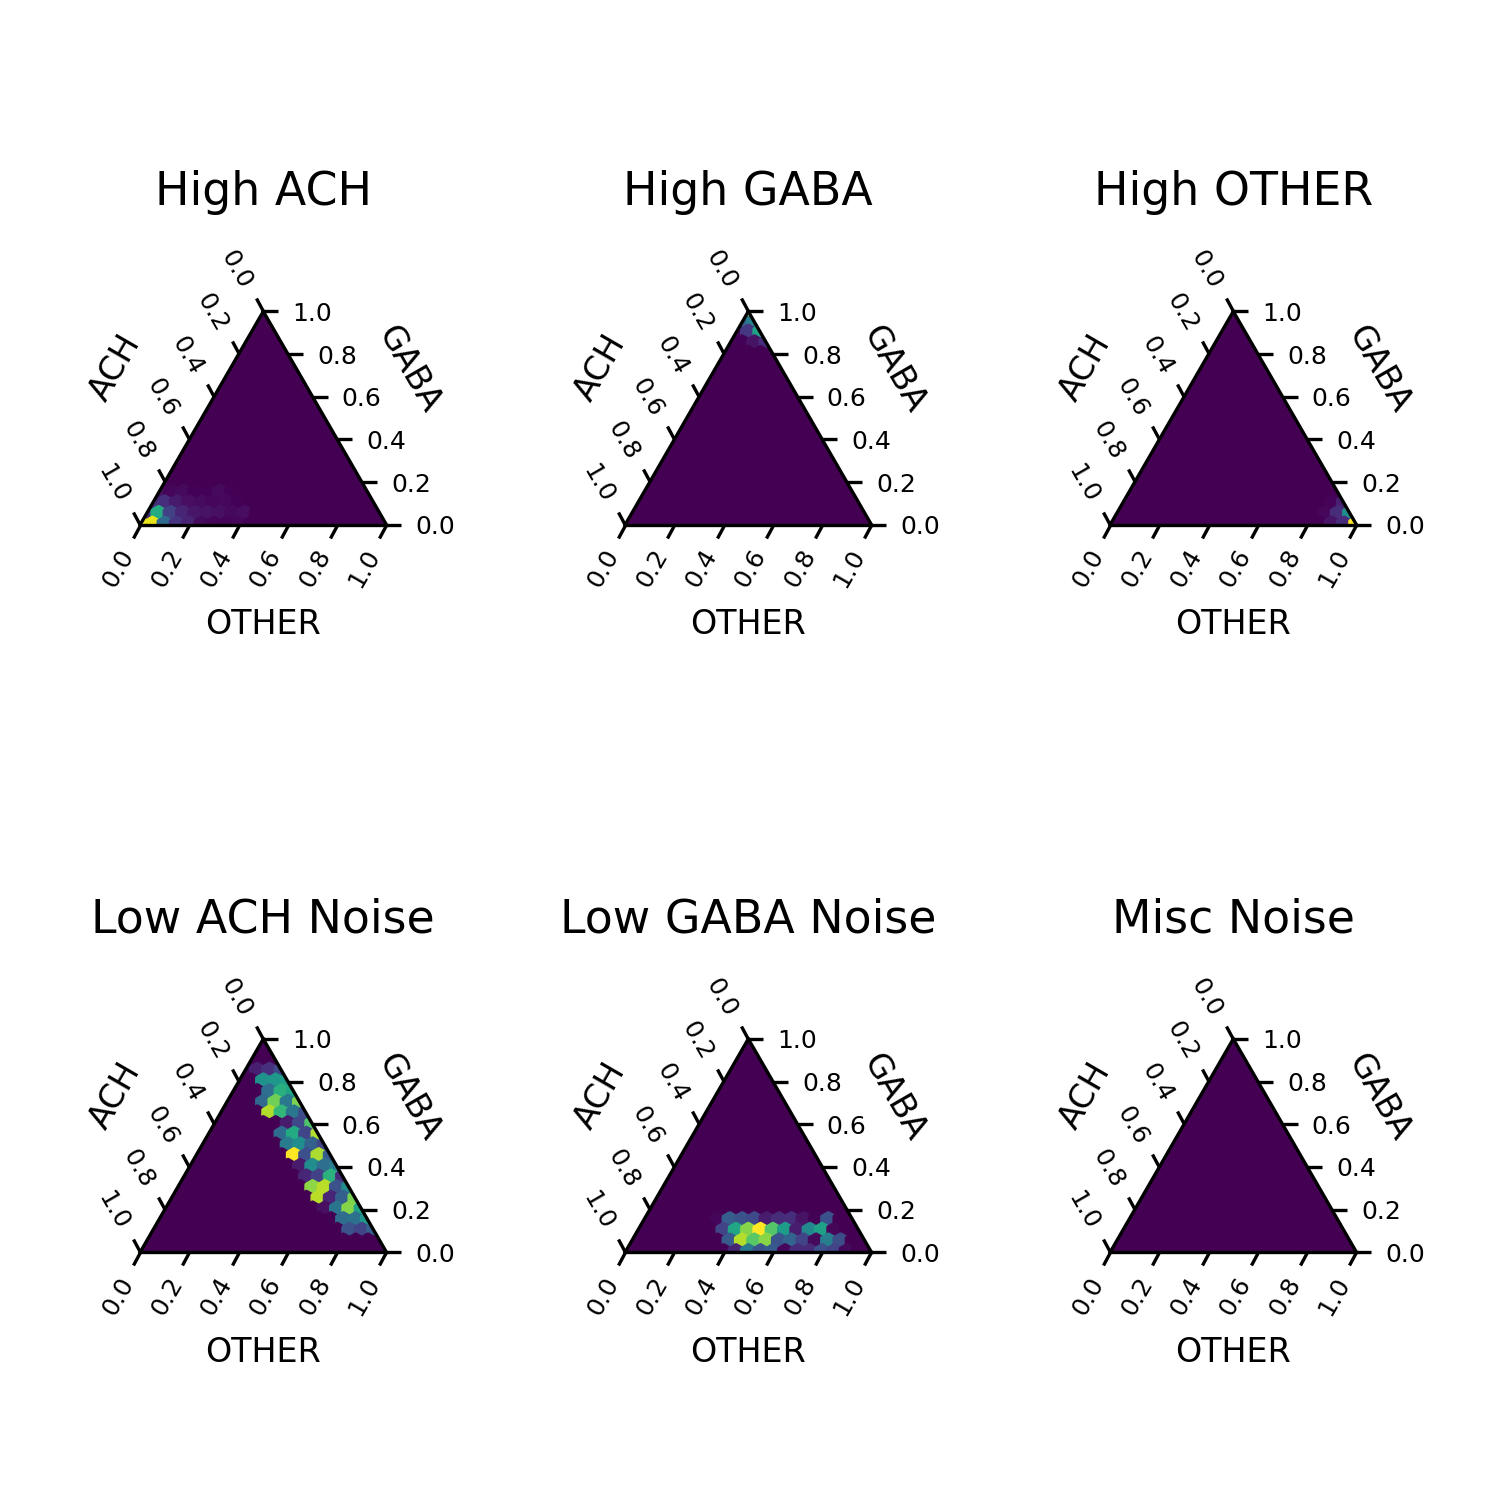

In [17]:
# Plot hex plots of new cluster classifications
grouped = sample.groupby("cluster")
high_gaba_sample = grouped.get_group("gaba")
high_ach_sample = grouped.get_group("ach")
high_other_sample = grouped.get_group("other")
low_ach_noise_sample = grouped.get_group("low_ach_noise")
low_gaba_noise_sample = grouped.get_group("low_gaba_noise")
misc_noise_sample = grouped.get_group("misc_noise")

filename = os.path.join(OUTDIR, "final_clusters.png")
pipeline.make_plot("plot_n_ternary", filename, 
                   samples = [high_gaba_sample, high_ach_sample, high_other_sample, 
                              low_ach_noise_sample, low_gaba_noise_sample, misc_noise_sample], 
                   labels = ["High_GABA", "High_ACH", "High_OTHER",
                             "Low_ACH_Noise", "Low_GABA_Noise", "Misc_Noise"])
Image(filename, width = 600)

### Generate Brain Map

I will use the same data points to generate the brain map as are used to generate the above 6 hex plots. These points will also be used downstream for statistical analysis, so will save to temp file for convenience.

In [18]:
sample_path = pipeline.make_temp_path()
sample.to_parquet(sample_path) # Create folder containing 1 parquet file per partition

In [26]:
brain_map_dir = os.path.join(OUTDIR, "brain_map")
pipeline.make_brain_map(sample_path, brain_map_dir)
IFrame(os.path.join(brain_map_dir, "bm_interactive.html"), width=800, height=600)

STDOUT: Call received!
Loading sampled connectome from file ...
C:\Users\cielb\Documents\coding\_NTPDVND\temp\b44f5189-1491-40dd-927b-e851dcadb926
Making brain map ...
16:57:17 Saving plots ...

STDERR: Traceback (most recent call last):
  File "C:\Users\cielb\anaconda3\envs\nta2\Lib\site-packages\pyvista\trame\jupyter.py", line 471, in elegantly_launch
    import nest_asyncio2  # noqa: PLC0415
    ^^^^^^^^^^^^^^^^^^^^
ModuleNotFoundError: No module named 'nest_asyncio2'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Users\cielb\Documents\coding\_NTPDVND\scripts\brainz.py", line 103, in <module>
    make_brain_map(connectome, outdir)
  File "C:\Users\cielb\Documents\coding\_NTPDVND\scripts\brainz.py", line 74, in make_brain_map
    save(plotter, actors, outdir)
  File "C:\Users\cielb\Documents\coding\_NTPDVND\scripts\brainz.py", line 82, in save
    plotter.export_html(os.path.join(outdir, "bm_interactive.html"))
  Fi

## Stage 3: Report & Visualise Neurotransmitter Probability Distributions Across Neuropils

### Summary Statistics For Each Neuropil

In [ ]:
neuropils = pipeline.get_neuropil_summary_stats(connectome)
filename = os.path.join(OUTDIR, "neuropil_summaries.csv")
neuropils.to_csv(filename)
neuropils.head(5) # See csv file for all neuropils

### Mean Neurotransmitter Probabilities With Respect To Neuropil Size

In [ ]:
filename = os.path.join(OUTDIR, "mean_nt_probs_by_neuropil_size.png")
pipeline.make_plot("plot_mean_nt_probs_by_neuropil_size", filename,
                   samples = [neuropils], 
                   labels = [""])
Image(filename, width = 600)

### Neurotransmitter Probability Variances With Respect To Neuropil Size

In [ ]:
filename = os.path.join(OUTDIR, "variance_by_neuropil_size.png")
pipeline.make_plot("plot_variance_by_neuropil_size", filename,
                  samples = [sample], labels = [""])
Image(filename, width = 600)

### Neuropil Neurotransmitter Probability Distributions By Region

In [ ]:
grouped_regions = sample.groupby("region")
regions = list(sample["region"].unique().compute())
for region in regions:
    df = grouped_regions.get_group(region)
    filename = os.path.join(OUTDIR, f"neuropil_distributions_{region}.png")
    pipeline.make_plot("plot_neuropils_in_region", filename,
                      samples = [df], labels = [region])

In [ ]:
#### Optic Lobe

In [ ]:
#### Lateral Complex

In [ ]:
#### Lateral Horn

In [ ]:
#### Periesophageal Neuropils

In [ ]:
#### Inferior Neuropils

In [ ]:
#### Ventromedial Neuropils

In [ ]:
#### Mushroom Body

In [ ]:
#### Antennal Lobe

In [ ]:
#### Superior Neuropils

In [ ]:
#### Ventrolateral Neuropils

In [ ]:
#### Central Complex

In [ ]:
#### Gnathal Ganglia

In [ ]:
#### Ocelli

In [ ]:
#### Other Regions

## Stage 4: Statistical Analysis

### Neurotransmitter Probabilities Across Different Brain Regions

I want to know whether neurotransmitter probabilities are different between neuropils. Because probabilities are a form of compositional data (the sum of the variables is 1, and each variable is bounded between 0 and 1), the Dirichlet distribution is suitable. This statistical analysis is a simple one based on average synapse probabilities within neuropils. A more statistically robust method would involve using the 'other' column to calculate the ranges of excitatory and inhibitory probabilities for each synaptic connection, then running a statistical analysis that can handle comparing range values within a bounded interval, e.g., Bayesian Dirichlet regression with interval priors. The Dirichlet function I used can only operate on points, not ranges. There does not appear to be an out-of-box Dirichlet regression function in any Python libraries, so I will interface with the R DirichletReg package via rpy2.

### Run statistical_analysis.R